<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 120 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">An End-to-End ML Project &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the cancellation model: a business-cost decision threshold, an engineered interaction feature, a tuned gradient-boosting rival, a probability-calibration check, and scoring a new booking end to end, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# An End-to-End ML Project: Take It Further
Five extensions of the Chapter 120 cancellation model, each worked in code with a picture and a plain explanation: tune the **decision threshold** to a business cost, **engineer an interaction** feature, **tune a gradient-boosting** rival, check **probability calibration**, and **score a new booking** end to end. We start by rebuilding the cleaned data and the fitted pipeline.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, precision_recall_curve, accuracy_score
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Same clean data, same pipeline</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 120, in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/hotel_bookings.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'hotel_bookings.csv')
df = df.drop_duplicates('booking_id'); df = df[df.lead_time>=0].copy()
tidy = lambda s: s.astype(str).str.strip().str.lower()
dep = {'no deposit':'No Deposit','non refund':'Non Refund','non-refund':'Non Refund','non-refundable':'Non Refund','refundable':'Refundable'}
df['deposit_type'] = tidy(df.deposit_type).map(lambda v: dep.get(v, v.title()))
seg = {'online ta':'Online TA','online travel agent':'Online TA','offline ta':'Offline TA','offline travel agent':'Offline TA','direct':'Direct','corporate':'Corporate','groups':'Groups','group':'Groups'}
df['market_segment'] = tidy(df.market_segment).map(lambda v: seg.get(v, v.title()))
numeric = ['lead_time','nights','adults','children','prior_cancellations','booking_changes','adr','total_special_requests','is_repeated_guest']
categorical = ['deposit_type','market_segment','customer_type']
def make_prep(num): return ColumnTransformer([('num', Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]), num), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
X = df[numeric+categorical]; y = df['is_canceled']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
model = Pipeline([('prep', make_prep(numeric)), ('clf', LogisticRegression(max_iter=3000, C=0.3))]).fit(X_train, y_train)
prob = model.predict_proba(X_test)[:,1]
print('recap: test AUC = %.3f (matches Chapter 120)' % roc_auc_score(y_test, prob))

recap: test AUC = 0.846 (matches Chapter 120)


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; A BUSINESS-COST THRESHOLD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">0.5 is rarely the right cutoff</div>
<div style="color:#4a5578;margin-top:6px">Pick the threshold that minimizes expected cost.</div>
</div>

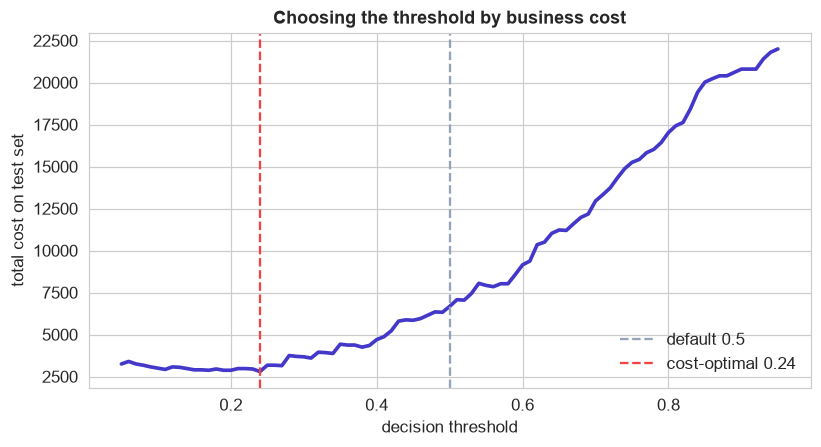

default 0.5 cost = 6675 | cost-optimal threshold 0.24


In [4]:
COST_MISS = 200   # a missed cancellation: a room left empty that could have been re-sold
COST_FALSE = 25   # a false alarm: an unnecessary confirmation call / small incentive
ths = np.linspace(0.05, 0.95, 91); costs = []
for t in ths:
    pred = (prob >= t).astype(int)
    fn = ((pred==0) & (y_test==1)).sum(); fp = ((pred==1) & (y_test==0)).sum()
    costs.append(fn*COST_MISS + fp*COST_FALSE)
best_t = ths[int(np.argmin(costs))]
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.plot(ths, costs, color=EM, lw=2.4); ax.axvline(0.5, color=GREY, ls='--', label='default 0.5')
ax.axvline(best_t, color=RED, ls='--', label=f'cost-optimal {best_t:.2f}'); ax.set(xlabel='decision threshold', ylabel='total cost on test set', title='Choosing the threshold by business cost'); ax.legend()
plt.tight_layout(); plt.show()
print(f'default 0.5 cost = {costs[list(ths).index(min(ths, key=lambda x: abs(x-0.5)))]:.0f} | cost-optimal threshold {best_t:.2f}')

**The threshold is a business decision, not a default.** Because a missed cancellation costs far more than a needless confirmation call, the expected-cost curve bottoms out **well below 0.5**: the hotel should flag a booking as risky at a *lower* probability, accepting more false alarms to catch more real cancellations. The model outputs a probability; *you* choose the cutoff to match what each type of error actually costs.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; ENGINEER AN INTERACTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Give the linear model what trees see for free</div>
<div style="color:#4a5578;margin-top:6px">A long lead time on a no-deposit booking is extra risky.</div>
</div>

CV AUC without interaction = 0.812
CV AUC with lead x no-deposit = 0.815


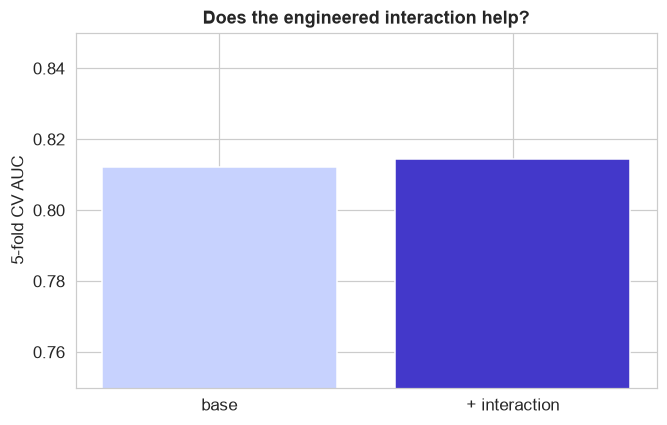

In [5]:
def add_interaction(frame):
    f = frame.copy(); f['lead_x_nodeposit'] = f['lead_time'] * (f['deposit_type']=='No Deposit').astype(int); return f
Xtr2, Xte2 = add_interaction(X_train), add_interaction(X_test)
num2 = numeric + ['lead_x_nodeposit']
base_auc = cross_val_score(Pipeline([('p',make_prep(numeric)),('c',LogisticRegression(max_iter=3000,C=0.3))]), X_train, y_train, cv=5, scoring='roc_auc').mean()
int_auc  = cross_val_score(Pipeline([('p',make_prep(num2)),('c',LogisticRegression(max_iter=3000,C=0.3))]), Xtr2, y_train, cv=5, scoring='roc_auc').mean()
print('CV AUC without interaction = %.3f' % base_auc)
print('CV AUC with lead x no-deposit = %.3f' % int_auc)
fig, ax = plt.subplots(figsize=(6.2,4))
ax.bar(['base','+ interaction'], [base_auc, int_auc], color=[LIGHT, EM]); ax.set(ylim=(0.75,0.85), ylabel='5-fold CV AUC', title='Does the engineered interaction help?')
plt.tight_layout(); plt.show()

**Feature engineering can close the gap.** A linear model cannot represent 'lead time matters *more* for no-deposit bookings' unless you build that product term for it, exactly the interaction a tree discovers automatically. Adding `lead_time x no-deposit` gives the logistic model a small but real lift, a reminder that thoughtful features often beat a fancier algorithm.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; A TUNED GRADIENT-BOOSTING RIVAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a flexible model overtake the linear one?</div>
<div style="color:#4a5578;margin-top:6px">Tune GBM properly, then judge on the test set.</div>
</div>

tuned GBM best params: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 300}
tuned GBM  test AUC = 0.850
logistic   test AUC = 0.846


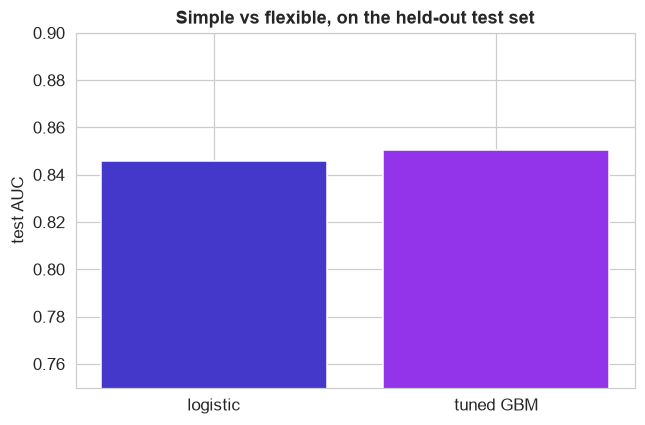

In [6]:
gb_grid = GridSearchCV(Pipeline([('prep', make_prep(numeric)), ('clf', GradientBoostingClassifier(random_state=0))]),
    {'clf__n_estimators':[150,300], 'clf__max_depth':[2,3], 'clf__learning_rate':[0.03,0.1]}, cv=5, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
gb_auc = roc_auc_score(y_test, gb_grid.predict_proba(X_test)[:,1])
print('tuned GBM best params:', {k.replace('clf__',''):v for k,v in gb_grid.best_params_.items()})
print('tuned GBM  test AUC = %.3f' % gb_auc)
print('logistic   test AUC = %.3f' % roc_auc_score(y_test, prob))
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['logistic','tuned GBM'], [roc_auc_score(y_test, prob), gb_auc], color=[EM, PUR]); ax.set(ylim=(0.75,0.9), ylabel='test AUC', title='Simple vs flexible, on the held-out test set')
plt.tight_layout(); plt.show()

**Flexible is not automatically better.** Even after a full grid search, the gradient-boosting model lands right around the logistic regression on this clean, mostly-linear data. When a simple model matches a complex one, prefer the simple one, it is faster, easier to explain, and less likely to break in production. Complexity should have to *earn* its place.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; ARE THE PROBABILITIES HONEST?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Calibration: does '70%' mean 70%?</div>
<div style="color:#4a5578;margin-top:6px">A reliability curve checks it.</div>
</div>

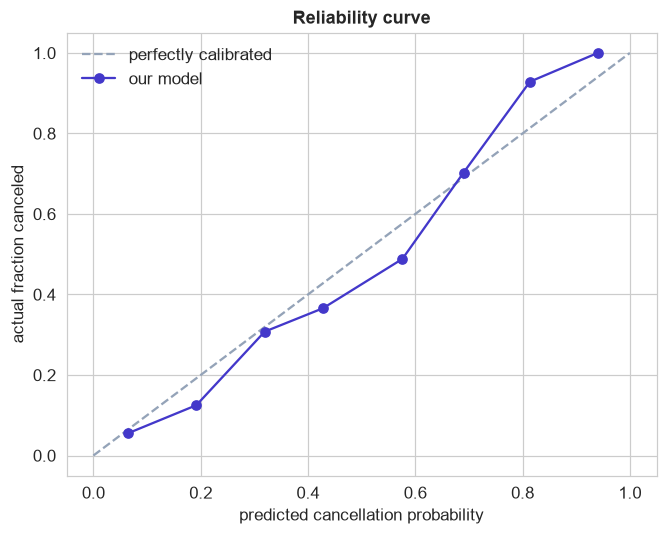

the points track the diagonal -> when the model says 0.7, about 70% really do cancel


In [7]:
frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=8)
fig, ax = plt.subplots(figsize=(6.2,5))
ax.plot([0,1],[0,1],'--',color=GREY,label='perfectly calibrated')
ax.plot(mean_pred, frac_pos, 'o-', color=EM, label='our model')
ax.set(xlabel='predicted cancellation probability', ylabel='actual fraction canceled', title='Reliability curve'); ax.legend()
plt.tight_layout(); plt.show()
print('the points track the diagonal -> when the model says 0.7, about 70% really do cancel')

**Calibrated probabilities can be trusted as probabilities.** A ranking metric like AUC only cares about order; but if you are going to *act* on 'this booking has a 70% chance of cancelling', that number had better be truthful. Logistic regression is naturally well-calibrated, the reliability curve hugs the diagonal, so the probabilities are safe to use directly in the cost calculation from Extension 1. (For models that are not calibrated, wrap them in `CalibratedClassifierCV`.)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; SCORE A NEW BOOKING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The model in action</div>
<div style="color:#4a5578;margin-top:6px">One row in, a risk score out.</div>
</div>

In [8]:
risky = pd.DataFrame([{'lead_time':240,'nights':2,'adults':2,'children':0,'prior_cancellations':1,'booking_changes':0,
    'adr':160,'total_special_requests':0,'is_repeated_guest':0,'deposit_type':'No Deposit','market_segment':'Groups','customer_type':'Transient'}])
safe = pd.DataFrame([{'lead_time':10,'nights':3,'adults':2,'children':1,'prior_cancellations':0,'booking_changes':1,
    'adr':120,'total_special_requests':3,'is_repeated_guest':1,'deposit_type':'Non Refund','market_segment':'Direct','customer_type':'Transient'}])
print('high-risk booking  -> cancel probability %.0f%%' % (model.predict_proba(risky)[0,1]*100))
print('low-risk booking   -> cancel probability %.0f%%' % (model.predict_proba(safe)[0,1]*100))

high-risk booking  -> cancel probability 95%
low-risk booking   -> cancel probability 0%


**This is what deployment delivers.** Feed the fitted pipeline a single new booking and it returns a cancellation probability, no manual preprocessing, because the pipeline carries it. A long-lead, no-deposit group booking with a prior cancellation scores very high; a last-minute, non-refundable, repeat-guest booking with special requests scores very low. Combine that score with the cost-based threshold and the hotel has an automated, explainable early-warning system.

## Take-it-further summary, in plain terms

- **The 0.5 cutoff is arbitrary**, set the threshold by what a miss vs a false alarm actually costs.
- **A hand-built interaction** let the simple model match what a tree gets for free.
- **A tuned boosting model tied the logistic one**, so we keep the simpler, explainable model.
- **The probabilities are calibrated**, '70%' really means about 70%, so they are safe to act on.
- **Scoring a booking is one line**, the deployed pipeline turns a raw record into a decision.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>